<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab9/Lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 9**

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
!pip install -q pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.5 MB/s eta 0:00:00


In [6]:
import yfinance as yf
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

## **Pregunta 1**

Descarga datos del `S&P500` para el período 1 de enero 2018 al 23 de septiembre del 2026. Calcula los retornos logarítmicos del S&P500.

In [7]:
# Descarga de datos
df = yf.download(['^GSPC'], start='2018-01-01', end='2026-09-24')['Close']

[*********************100%***********************]  1 of 1 completed


## **Pregunta 2**

Muestra las primeras 10 observaciones y las últimas 10 observaciones.

In [8]:
df.head(10)

Ticker,^GSPC
Date,
2018-01-02,2695.810059
2018-01-03,2713.060059
2018-01-04,2723.989990
2018-01-05,2743.149902
2018-01-08,2747.709961
2018-01-09,2751.290039
2018-01-10,2748.229980
2018-01-11,2767.560059
2018-01-12,2786.239990


In [9]:
df.tail(10)

Ticker,^GSPC
Date,
2026-09-10,7591.700195
2026-09-11,7656.979980
2026-09-14,7619.979980
2026-09-15,7585.729980
2026-09-16,7551.810059
2026-09-17,7637.759766
2026-09-18,7650.500000
2026-09-21,7764.700195
2026-09-22,7764.640137


## **Pregunta 3**

Grafica la serie del S&P500, la función de autocorrelación y la función de autocorrelación parcial.

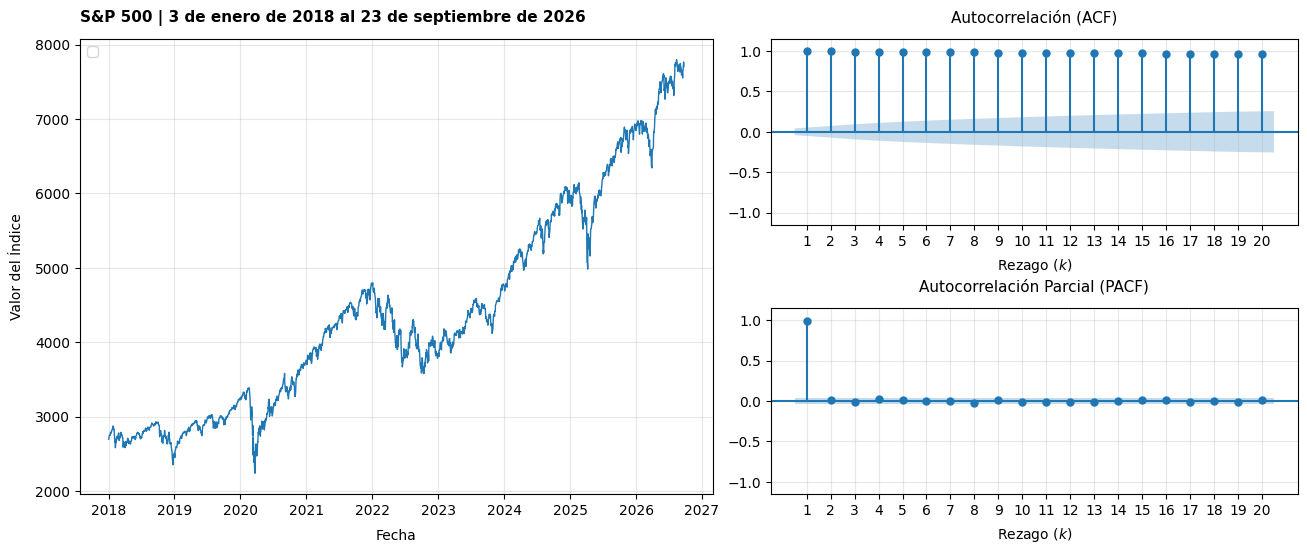

In [10]:
serie_sp500 = df["^GSPC"].dropna()

# Gráficos
fig = plt.figure(figsize=(14, 5))

gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1], hspace=0.45, wspace=0.1)

lags_mostrar = 20

# COLUMNA 1: Serie del S&P 500
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(
    serie_sp500.index,
    serie_sp500.values,
    color="#1f77b4",
    linewidth=1,
)
ax1.set_title(
    'S&P 500 | 3 de enero de 2018 al 23 de septiembre de 2026', loc='left',
    fontsize=11,
    fontweight="bold",
    pad=12,
)
ax1.set_xlabel("Fecha", labelpad=8)
ax1.set_ylabel("Valor del Índice", labelpad=8)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): ACF
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(
    serie_sp500,
    ax=ax2,
    lags=lags_mostrar,
    zero=False,
    title="Autocorrelación (ACF)",
)
ax2.set_title("Autocorrelación (ACF)", fontsize=11, pad=12)
ax2.set_xlabel("Rezago ($k$)", labelpad=6)
ax2.set_xticks(range(1, lags_mostrar + 1))

ax2.set_ylim(-1.15, 1.15)
ax2.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (Inferior): PACF
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    serie_sp500,
    ax=ax3,
    lags=lags_mostrar,
    zero=False,
    title="Autocorrelación Parcial (PACF)",
    method="ywm",
)
ax3.set_title("Autocorrelación Parcial (PACF)", fontsize=11, pad=12)
ax3.set_xlabel("Rezago ($k$)", labelpad=6)
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.15, 1.15)
ax3.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax3.grid(True, alpha=0.3)


plt.subplots_adjust(top=0.92, bottom=0.01, left=0.08, right=0.95)

plt.show()

## **Pregunta 4**

¿Es estacionaria la serie del S&P500?

In [11]:
# PRUEBA ADF: S&P500
adf_sp500= adfuller(df['^GSPC'])
print(f"S&P 500 | p-value: {adf_sp500[1]:.4f} | {'No Estacionaria' if adf_sp500[1] >= 0.05 else 'Estacionaria'}")




S&P 500 | p-value: 0.9902 | No Estacionaria


## **Pregunta 5**

Grafica los retornos del S&P500, la función de autocorrelación y la función de autocorrelación parcial.

In [12]:
# Cálculo de log-retornos
retorno_sp500 = np.log(df['^GSPC'] / df['^GSPC'].shift(1)).dropna()

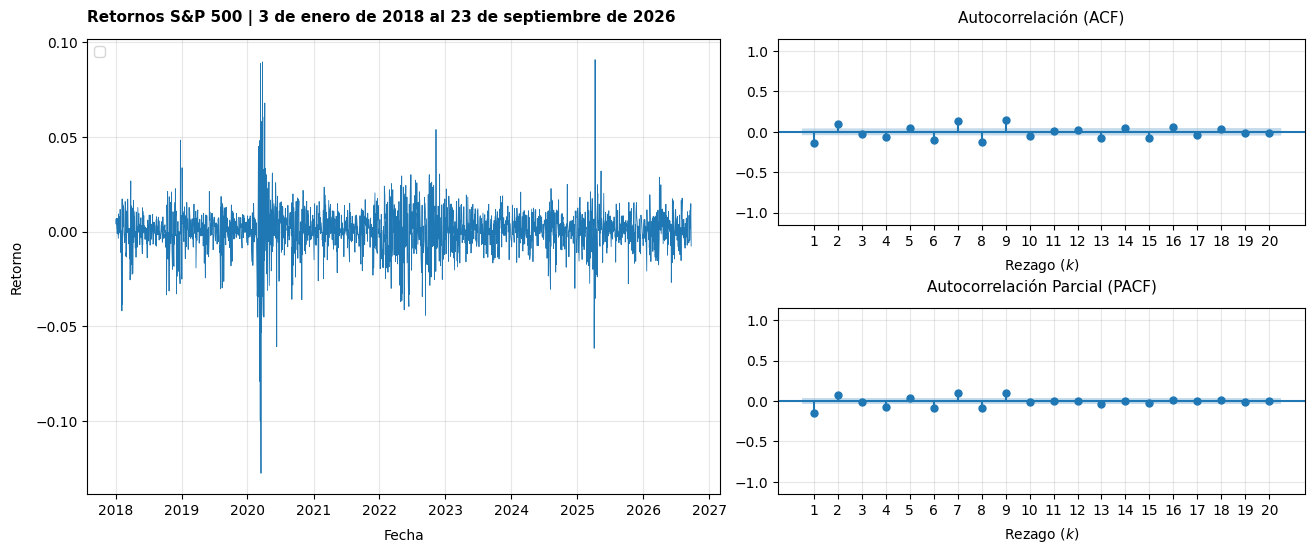

In [14]:
# Gráficos
fig = plt.figure(figsize=(14, 5))

gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1], hspace=0.45, wspace=0.1)

lags_mostrar = 20

# COLUMNA 1: Serie del S&P 500
ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(
    retorno_sp500.index,
    retorno_sp500.values,
    color="#1f77b4",
    linewidth=0.6,
)
ax1.set_title(
    'Retornos S&P 500 | 3 de enero de 2018 al 23 de septiembre de 2026', loc='left',
    fontsize=11,
    fontweight="bold",
    pad=12,
)
ax1.set_xlabel("Fecha", labelpad=8)
ax1.set_ylabel("Retorno", labelpad=8)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# COLUMNA 2 (superior): ACF
ax2 = fig.add_subplot(gs[0, 1])
plot_acf(
    retorno_sp500,
    ax=ax2,
    lags=lags_mostrar,
    zero=False,
    title="Autocorrelación (ACF)",
)
ax2.set_title("Autocorrelación (ACF)", fontsize=11, pad=12)
ax2.set_xlabel("Rezago ($k$)", labelpad=6)
ax2.set_xticks(range(1, lags_mostrar + 1))

ax2.set_ylim(-1.15, 1.15)
ax2.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax2.grid(True, alpha=0.3)

# COLUMNA 2 (Inferior): PACF
ax3 = fig.add_subplot(gs[1, 1])
plot_pacf(
    retorno_sp500,
    ax=ax3,
    lags=lags_mostrar,
    zero=False,
    title="Autocorrelación Parcial (PACF)",
    method="ywm",
)
ax3.set_title("Autocorrelación Parcial (PACF)", fontsize=11, pad=12)
ax3.set_xlabel("Rezago ($k$)", labelpad=6)
ax3.set_xticks(range(1, lags_mostrar + 1))
ax3.set_ylim(-1.15, 1.15)
ax3.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax3.grid(True, alpha=0.3)


plt.subplots_adjust(top=0.92, bottom=0.01, left=0.08, right=0.95)

plt.show()

## **Pregunta 6**

¿Es estacionaria la serie de los retornos del S&P500?

In [16]:
# PRUEBA ADF: S&P500
adf_retornos_sp500= adfuller(retorno_sp500)
print(f"Retornos S&P 500 | p-value: {adf_retornos_sp500[1]:.4f} | {'No Estacionaria' if adf_retornos_sp500[1] >= 0.05 else 'Estacionaria'}")


Retornos S&P 500 | p-value: 0.0000 | Estacionaria


## **Pregunta 7**

Separa los datos en conjunto de datos de entrenamiento (80%) y de prueba (20%)

In [17]:
train_size = int(len(retorno_sp500) * 0.80)
train_retornos = retorno_sp500.iloc[:train_size]
test_retornos = retorno_sp500.iloc[train_size:]



In [18]:
test_retornos.head()

,^GSPC
Date,
2024-12-20,0.010810
2024-12-23,0.007261
2024-12-24,0.010982
2024-12-26,-0.000406
2024-12-27,-0.011117


In [19]:
test_retornos.tail()

,^GSPC
Date,
2026-09-17,0.011317
2026-09-18,0.001667
2026-09-21,0.014817
2026-09-22,-0.000008
2026-09-23,-0.007577


## **Pregunta 8**

Usando la función `auto_arima` selecciona un modelo para la serie de los retornos del S&P500. ¿Eligen el mismo modelo los criterios de información de Akaike y el Bayesiano?

In [21]:
modelo_sp500_aic = pm.auto_arima(
    train_retornos, start_p=0, start_q=0, max_p=3, max_q=3,
    seasonal=False, information_criterion='aic',
    stepwise=True, suppress_warnings=True
)

print(f'Modelo óptimo por AIC: ARIMA{modelo_sp500_aic.order}')
print(modelo_sp500_aic.summary())

Modelo óptimo por AIC: ARIMA(2, 0, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1753
Model:               SARIMAX(2, 0, 0)   Log Likelihood                5224.031
Date:                Fri, 25 Sep 2026   AIC                         -10440.063
Time:                        15:44:57   BIC                         -10418.186
Sample:                             0   HQIC                        -10431.977
                               - 1753                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0005      0.000      1.465      0.143      -0.000       0.001
ar.L1         -0.1437      0.011    -13.560      0.000      -0.164      -0.123
ar.L2         

In [22]:
modelo_sp500_bic = pm.auto_arima(
    train_retornos, start_p=0, start_q=0, max_p=3, max_q=3,
    d=0, seasonal=False, information_criterion='bic',
    stepwise=True, suppress_warnings=True
)

print(f'Modelo óptimo por BIC: ARIMA{modelo_sp500_bic.order}')
print(modelo_sp500_bic.summary())

Modelo óptimo por BIC: ARIMA(2, 0, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1753
Model:               SARIMAX(2, 0, 0)   Log Likelihood                5222.751
Date:                Fri, 25 Sep 2026   AIC                         -10439.502
Time:                        15:45:10   BIC                         -10423.095
Sample:                             0   HQIC                        -10433.438
                               - 1753                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1421      0.010    -13.962      0.000      -0.162      -0.122
ar.L2          0.0813      0.009      8.595      0.000       0.063       0.100
sigma2        

## **Pregunta 9**

Usando el modelo seleccionado ARIMA $(2,0,0)$ sin intercepto (ver modelo seleccionado usando BIC), realiza proyecciones del S&P500 en el *test set*. Grafica la serie observada y predicha.

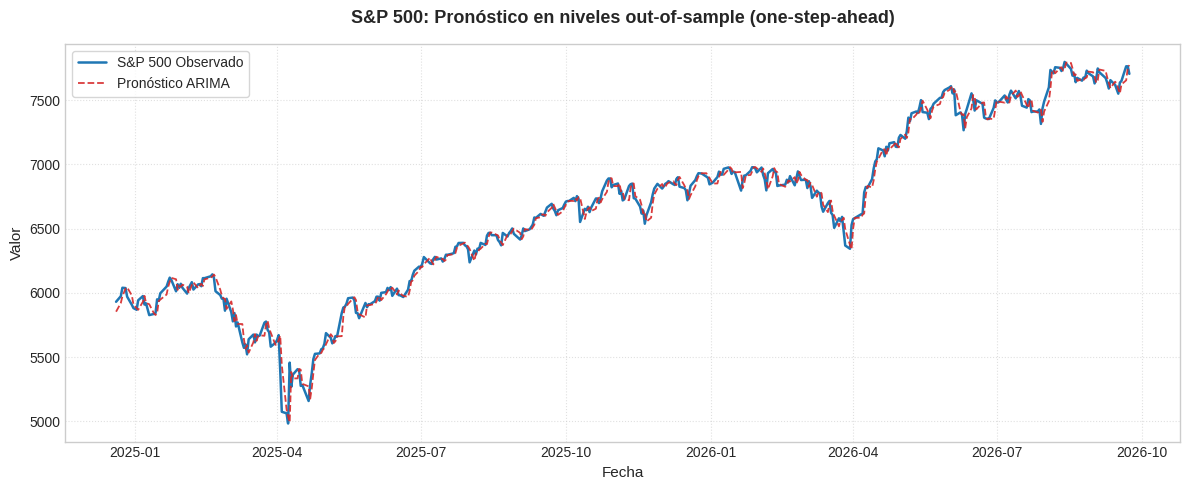

In [24]:
history_retornos = list(train_retornos)
pred_retornos = []
pred_sp500 = []
test_sp500_aligned = []

for date in test_retornos.index:
    idx_loc = serie_sp500.index.get_loc(date)
    current_sp500 = serie_sp500.iloc[idx_loc - 1]

    model = SARIMAX(
        history_retornos, order=(2, 0, 0), trend='n', enforce_stationarity=False
    )
    model_fit = model.fit(disp=False)

    r_hat = model_fit.forecast(steps=1)[0]
    pred_retornos.append(r_hat)

    p_hat = current_sp500 * np.exp(r_hat)
    pred_sp500.append(p_hat)

    test_sp500_aligned.append(serie_sp500.loc[date])
    history_retornos.append(test_retornos.loc[date])


results_df = pd.DataFrame(
    {
        'Indice_Observado': test_sp500_aligned,
        'Indice_Predicho': pred_sp500,
        'Retorno_Observado': test_retornos.values,
        'Retorno_Predicho': pred_retornos,
    },
    index=test_retornos.index,
)

plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)
plt.figure(figsize=(12, 5))

plt.plot(
    results_df.index,
    results_df['Indice_Observado'],
    label='S&P 500 Observado',
    color='#1f77b4',
    linewidth=1.8,
)
plt.plot(
    results_df.index,
    results_df['Indice_Predicho'],
    label=f'Pronóstico ARIMA',
    color='#d62728',
    linestyle='--',
    linewidth=1.3,
    alpha=0.9,
)

plt.title(
    'S&P 500: Pronóstico en niveles out-of-sample (one-step-ahead)',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Valor', fontsize=11)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()



## **Pregunta 10**

Calcula el RMSE y MAE

In [27]:
rmse_sp500 = np.sqrt(
    np.mean((results_df['Indice_Observado'] - results_df['Indice_Predicho']) ** 2)
)

mae_sp500 = np.mean(
    np.abs(results_df['Indice_Observado'] - results_df['Indice_Predicho'])
)

print(f'RMSE: {rmse_sp500:.2f}')
print(f'MAE: {mae_sp500:.2f}')

RMSE: 63.76
MAE: 45.19


## **Pregunta 11**

Compara el desempeño del modelo ARIMA(2,0,0) sin intercepto con un modelo *naive* que predice el próximo valor como el último valor observado.

RMSE (Modelo Naive): 63.67
MAE (Modelo Naive): 44.89

RMSE (Modelo SARIMAX): 63.76
MAE (Modelo SARIMAX): 45.19


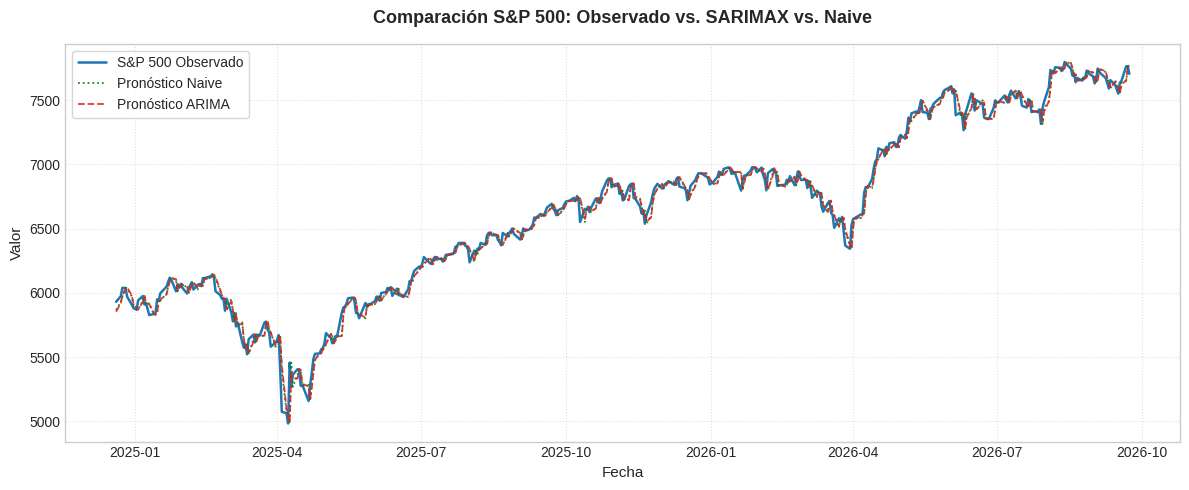

In [30]:
last_train_date = train_retornos.index[-1]
last_sp500_value_before_test = serie_sp500.loc[last_train_date]

naive_predictions = [last_sp500_value_before_test]
naive_predictions.extend(results_df['Indice_Observado'].iloc[:-1].tolist())

naive_predictions_series = pd.Series(naive_predictions, index=results_df.index)

# Calcular RMSE y MAE para el modelo ingenuo
rmse_naive = np.sqrt(
    np.mean((results_df['Indice_Observado'] - naive_predictions_series) ** 2)
)
mae_naive = np.mean(
    np.abs(results_df['Indice_Observado'] - naive_predictions_series)
)

print(f'RMSE (Modelo Naive): {rmse_naive:.2f}')
print(f'MAE (Modelo Naive): {mae_naive:.2f}')
print(f'\nRMSE (Modelo SARIMAX): {rmse_sp500:.2f}')
print(f'MAE (Modelo SARIMAX): {mae_sp500:.2f}')

# Opcional: Graficar las predicciones ingenuas para una comparación visual
plt.figure(figsize=(12, 5))
plt.plot(
    results_df.index,
    results_df['Indice_Observado'],
    label='S&P 500 Observado',
    color='#1f77b4',
    linewidth=1.8,
)
plt.plot(
    results_df.index,
    naive_predictions_series,
    label='Pronóstico Naive',
    color='green',
    linestyle=':',
    linewidth=1.3,
    alpha=0.9,
)
plt.plot(
    results_df.index,
    results_df['Indice_Predicho'],
    label='Pronóstico ARIMA',
    color='#d62728',
    linestyle='--',
    linewidth=1.3,
    alpha=0.9,
)

plt.title(
    'Comparación S&P 500: Observado vs. SARIMAX vs. Naive',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Valor', fontsize=11)
plt.legend(loc='upper left', frameon=True, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

El modelo *naive* muestra un rendimiento ligeramente superior al modelo ARIMA, con un RMSE y MAE marginalmente más bajos. Esto podría sugerir que para esta serie de datos y el período de pronóstico, el modelo ARIMA no está capturando suficiente información adicional para superar la simplicidad de simplemente usar el último valor observado como predicción para el siguiente paso. A veces, para series con alta aleatoriedad o movimientos erráticos, un modelo *naive* puede ser un punto de referencia sorprendentemente difícil de superar.